# Backtesting the 'buying-the-dip' Trading Strategy

## Libraries and settings

In [1]:
# Libraries
import os
import warnings
from datetime import datetime

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Ignore warnings
warnings.filterwarnings("ignore")

# Current working directory
print(f'Current working directory: {os.getcwd()}')

Current working directory: /workspaces/data_ingestion/04_Yahoo_Finance_WebAPI


## Historical Data iShares Core MSCI World UCITS ETF

In [2]:
# Get today's date
today = datetime.today().strftime('%Y-%m-%d')

# Load historical data iShares Core MSCI World UCITS ETF
ticker = 'IWDA.AS'
df = yf.download(
    ticker,
    start='2010-01-01',
    end=today,
    interval='1mo',
    multi_level_index=False,
    progress=False,
)

# Check currency
ticker = yf.Ticker("IWDA.AS")
print(
    f"The currency used by yfinance is: "
    f"{ticker.info['currency']}"
)

# Monthly return
df['Monthly_Return'] = df['Close'].pct_change()
df

The currency used by yfinance is: EUR


,Close,High,Low,Open,Volume,Monthly_Return
Date,,,,,,
2010-01-01,17.940001,18.600000,17.770000,18.070000,14303,NaN
2010-02-01,18.379999,18.620001,17.139999,17.820000,86540,0.024526
2010-03-01,19.660000,19.930000,18.549999,18.559999,114226,0.069641
2010-04-01,20.090000,20.469999,19.770000,19.770000,7314,0.021872
2010-05-01,19.549999,20.415001,18.580000,20.070000,35831,-0.026879
...,...,...,...,...,...,...
2026-04-01,117.055000,117.389999,108.695000,110.209999,1936757,0.083291
2026-05-01,123.379997,123.800003,117.055000,117.055000,2374519,0.054034
2026-06-01,125.129997,125.800003,120.300003,123.830002,2259633,0.014184


## Backtesting buying-the-dip versus fixed monthly investment Strategy

In [3]:
# Strategy 1: Invest a fixed amount every month
fixed_investment = 1000
df['Fixed Investment'] = fixed_investment
df['Fixed Shares'] = df['Fixed Investment'] / df['Close']
df['Fixed Total Shares'] = df['Fixed Shares'].cumsum()
df['Fixed Portfolio Value'] = df['Fixed Total Shares'] * df['Close']

# Strategy 2: Invest cumulative monthly savings after a drop of X%
threshold = 0.05
monthly_savings = 1000
df['Trigger Investment'] = 0.0
df['Trigger Shares'] = 0.0
savings = 0.0

# Ensure that the index is a simple integer
df = df.reset_index()

for i in range(1, len(df)):
    if threshold == 0.00:
        # Invest fixed savings every month if the threshold is 0
        df.loc[i, 'Trigger Investment'] = monthly_savings
    else:
        # Accumulate savings if the threshold is > 0
        savings += monthly_savings
        current_close = float(df.at[i, 'Close'])
        previous_close = float(df.at[i - 1, 'Close'])

        # Invest accumulated savings after the threshold drop
        if current_close <= previous_close * (1 - threshold):
            df.loc[i, 'Trigger Investment'] = savings
            savings = 0

    # Calculate the number of shares bought
    current_close = float(df.at[i, 'Close'])
    df.loc[i, 'Trigger Shares'] = (
        df.loc[i, 'Trigger Investment'] / current_close
    )

# Calculate the total number of shares and the portfolio value
df['Trigger Total Shares'] = df['Trigger Shares'].cumsum()
df['Trigger Portfolio Value'] = df['Trigger Total Shares'] * df['Close']

# Output the final portfolio values
print(
    "Final portfolio value with fixed monthly investment: "
    f"{df['Fixed Portfolio Value'].iloc[-1]:.2f} EUR"
)
print(
    "Final portfolio value with investment after a drop: "
    f"{df['Trigger Portfolio Value'].iloc[-1]:.2f} EUR"
)

# Difference in portfolio values
diff = (
    df['Trigger Portfolio Value'].iloc[-1]
    - df['Fixed Portfolio Value'].iloc[-1]
)
print(f"\nDifference in portfolio values: {diff:.2f} EUR")

Final portfolio value with fixed monthly investment: 635437.56 EUR
Final portfolio value with investment after a drop: 545592.89 EUR

Difference in portfolio values: -89844.66 EUR


## Plot the results

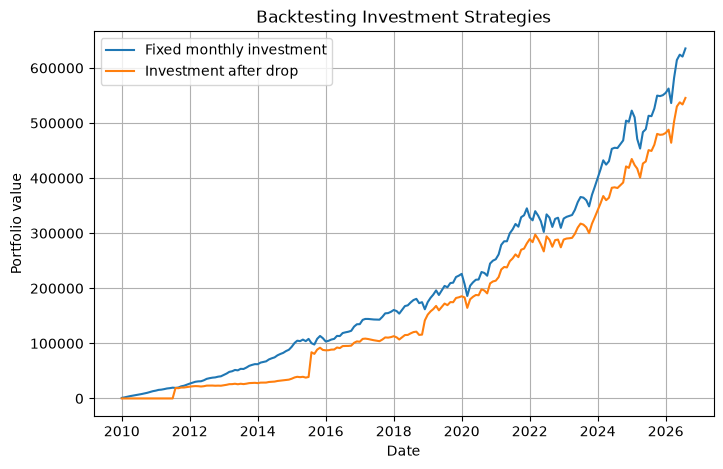

In [4]:
# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(
    df['Date'],
    df['Fixed Portfolio Value'],
    label='Fixed monthly investment',
)
plt.plot(
    df['Date'],
    df['Trigger Portfolio Value'],
    label='Investment after drop',
)
plt.title('Backtesting Investment Strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio value')
plt.legend()
plt.grid(True)
plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [5]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1052-azure
Datetime: 2026-08-20 06:01:14
Python Version: 3.12.13
-----------------------------------
